# Installations

In [ ]:
# pip install tensorflow yfinance seaborn xgboost arch scikit-learn

# Volatility Forecasting for BTC and ETH

In [18]:
"""
Cryptocurrency Volatility Forecasting
Models: Naive Baseline, Random Forest, LSTM, XGBoost
Data:   BTC-USD & ETH-USD hourly, Jul 2024 – Sep 2025

MODIFIED: every chart is rendered with a transparent background and
auto-saved as a PNG to /mnt/user-data/outputs/charts/
"""

# =============================================================================
# 0. REPRODUCIBILITY & IMPORTS
# =============================================================================
import os, gc, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
import xgboost as xgb

OUT_DIR = "/Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs"  # saves into a "charts" folder next to your notebook
os.makedirs(OUT_DIR, exist_ok=True)
_fig_counter = {"n": 0}

def save_and_show(fig, name: str):
    """Save figure as a transparent PNG, then display it."""
    _fig_counter["n"] += 1
    fname = f"{_fig_counter['n']:02d}_{name}.png"
    path = os.path.join(OUT_DIR, fname)
    fig.savefig(path, transparent=True, facecolor="none", bbox_inches="tight", dpi=150)
    print(f"Saved transparent chart -> {path}")
    plt.show()

# ── Presentation-grade plot style (transparent backgrounds) ─────────────────
plt.rcParams.update({
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "axes.facecolor":   "none",
    "axes.edgecolor":   "#000000",
    "axes.labelcolor":  "#000000",
    "axes.titlecolor":  "#000000",
    "xtick.color":      "#000000",
    "ytick.color":      "#000000",
    "grid.color":       "#cccccc",
    "grid.linewidth":   0.8,
    "text.color":       "#000000",
    "legend.facecolor": "none",
    "legend.edgecolor": "#000000",
    "font.family":      "monospace",
    "figure.dpi":       150,
})
COLORS = {
    "actual":  "#58a6ff",
    "rf":      "#3fb950",
    "lstm":    "#f78166",
    "xgb":     "#d2a8ff",
    "naive":   "#ffa657",
    "accent":  "#000000",
}

# =============================================================================
# 1. UTILITIES
# =============================================================================
ANNUALISE = np.sqrt(24 * 365)
WINDOW    = 30

def garman_klass_vol(df: pd.DataFrame) -> pd.Series:
    log_hl = np.log(df["High"] / df["Low"])
    log_co = np.log(df["Close"] / df["Open"])
    gk_var = 0.5 * log_hl**2 - (2 * np.log(2) - 1) * log_co**2
    gk_var = gk_var.clip(lower=0)
    return np.sqrt(gk_var) * ANNUALISE

def add_vol_columns(df: pd.DataFrame, window: int = WINDOW) -> pd.DataFrame:
    df = df.copy()
    df["log_returns"]     = np.log(df["Close"] / df["Close"].shift(1))
    df["squared_returns"] = df["log_returns"] ** 2
    df["realized_vol"]    = df["log_returns"].rolling(window).std() * ANNUALISE
    df["gk_vol"]          = garman_klass_vol(df)
    return df.dropna()

def create_volatility_features(data: pd.DataFrame, lags: int = 5) -> pd.DataFrame:
    f = pd.DataFrame(index=data.index)
    for i in range(1, lags + 1):
        f[f"returns_lag_{i}"]    = data["log_returns"].shift(i)
        f[f"sq_returns_lag_{i}"] = data["squared_returns"].shift(i)
        f[f"vol_lag_{i}"]        = data["realized_vol"].shift(i)
    f["vol_ma_5"]      = data["realized_vol"].rolling(5).mean()
    f["vol_ma_10"]     = data["realized_vol"].rolling(10).mean()
    f["returns_ma_5"]  = data["log_returns"].rolling(5).mean()
    f["returns_std_5"] = data["log_returns"].rolling(5).std()
    f["gk_vol"]        = data["gk_vol"]
    f["gk_vol_ma_5"]   = data["gk_vol"].rolling(5).mean()
    return f

def make_xy(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    feat     = create_volatility_features(data)
    target   = data["realized_vol"].shift(-1)
    combined = pd.concat([feat, target.rename("target")], axis=1).dropna()
    X = combined.drop(columns="target")
    y = combined["target"]
    return X, y

def create_sequences(X: np.ndarray, y: np.ndarray, window: int = 24):
    n = len(X) - window
    X_seq = np.stack([X[i : i + window] for i in range(n)])
    y_seq = y[window:]
    return X_seq, y_seq

## Data and train

In [19]:
# =============================================================================
# 2. BTC-USD FULL WORKFLOW (RESTORED TO ORIGINAL)
# =============================================================================
print("Downloading BTC-USD hourly data …")
btc = yf.download("BTC-USD", start="2024-09-01", end="2025-11-01", interval="1h", auto_adjust=True)
btc.columns = btc.columns.get_level_values(0)

train_ratio = 14 / 18
split_idx   = int(len(btc) * train_ratio)
btc_train = add_vol_columns(btc.iloc[:split_idx])
btc_test  = add_vol_columns(btc.iloc[split_idx:])

X_train, y_train = make_xy(btc_train)
X_test,  y_test  = make_xy(btc_test)

[*********************100%***********************]  1 of 1 completed

## Naive Baseline

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/01_btc_naive_timeseries.png


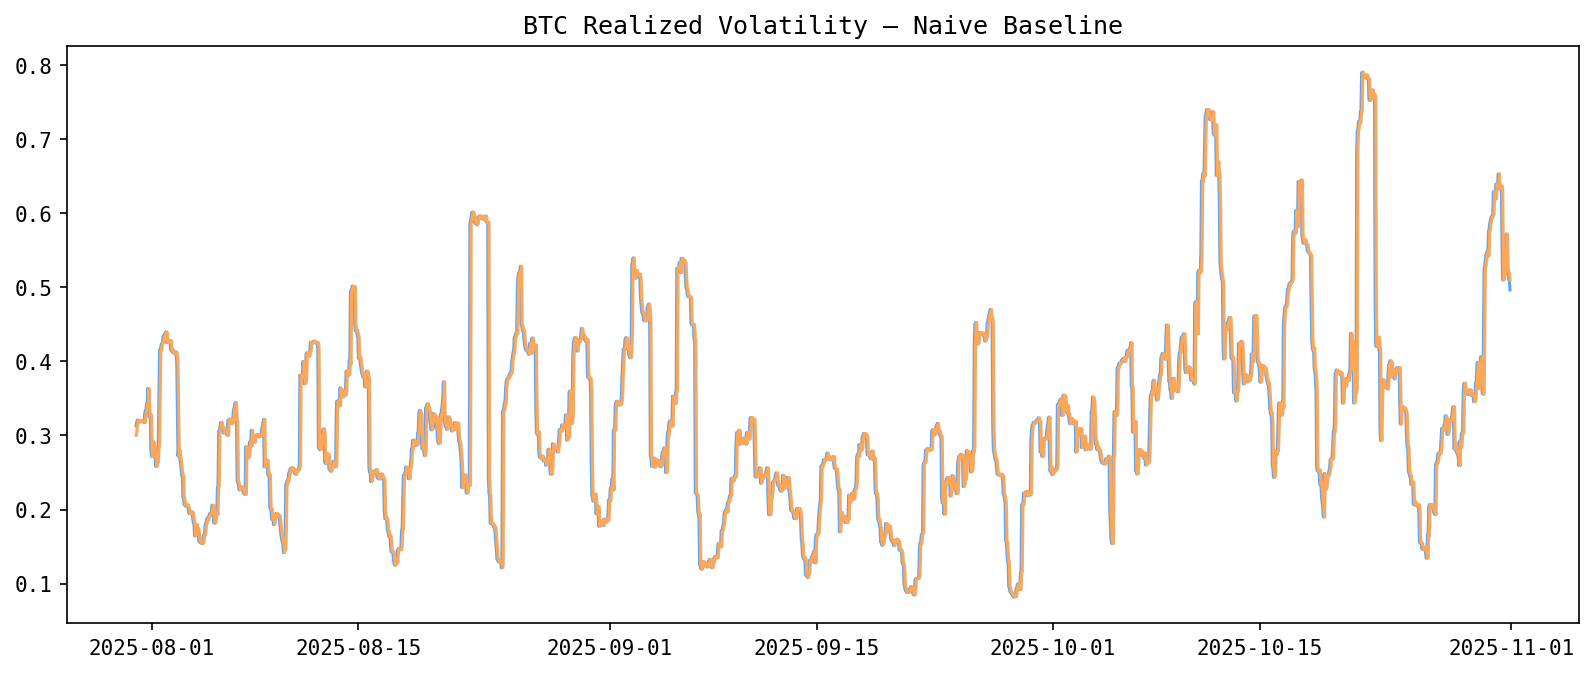

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/02_btc_naive_scatter.png


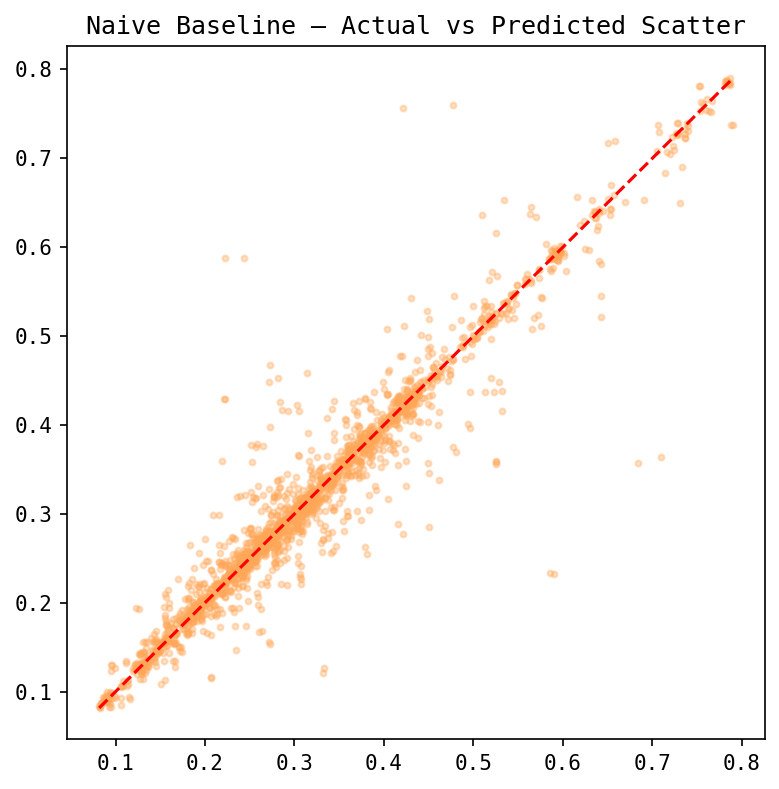

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/03_btc_naive_residuals.png


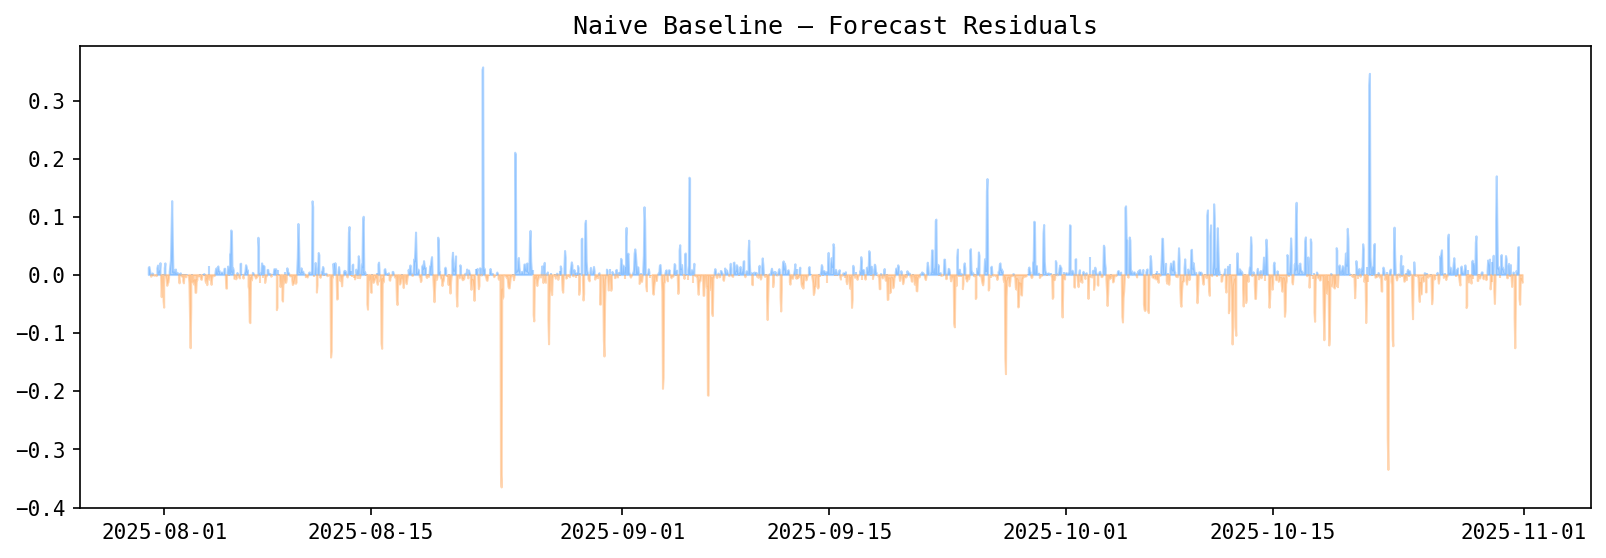

In [20]:
# --- NAIVE ---
naive_preds = X_test["vol_lag_1"]
rmse_naive, mae_naive, r2_naive = np.sqrt(mean_squared_error(y_test, naive_preds)), mean_absolute_error(y_test, naive_preds), r2_score(y_test, naive_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index, y_test.values, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index, naive_preds.values, color=COLORS["naive"], label="Naive")
ax.set_title("BTC Realized Volatility — Naive Baseline")
save_and_show(fig, "btc_naive_timeseries")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test.values, naive_preds.values, alpha=0.35, s=8, color=COLORS["naive"])
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
ax.set_title("Naive Baseline — Actual vs Predicted Scatter")
save_and_show(fig, "btc_naive_scatter")

fig, ax = plt.subplots(figsize=(13, 4))
res = y_test.values - naive_preds.values
ax.fill_between(y_test.index, res, 0, where=(res >= 0), color=COLORS["actual"], alpha=0.45)
ax.fill_between(y_test.index, res, 0, where=(res < 0),  color=COLORS["naive"],  alpha=0.45)
ax.set_title("Naive Baseline — Forecast Residuals")
save_and_show(fig, "btc_naive_residuals")

## Random Forest

Best RF params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 5}  (CV RMSE=0.0460)
Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/04_btc_rf_timeseries.png


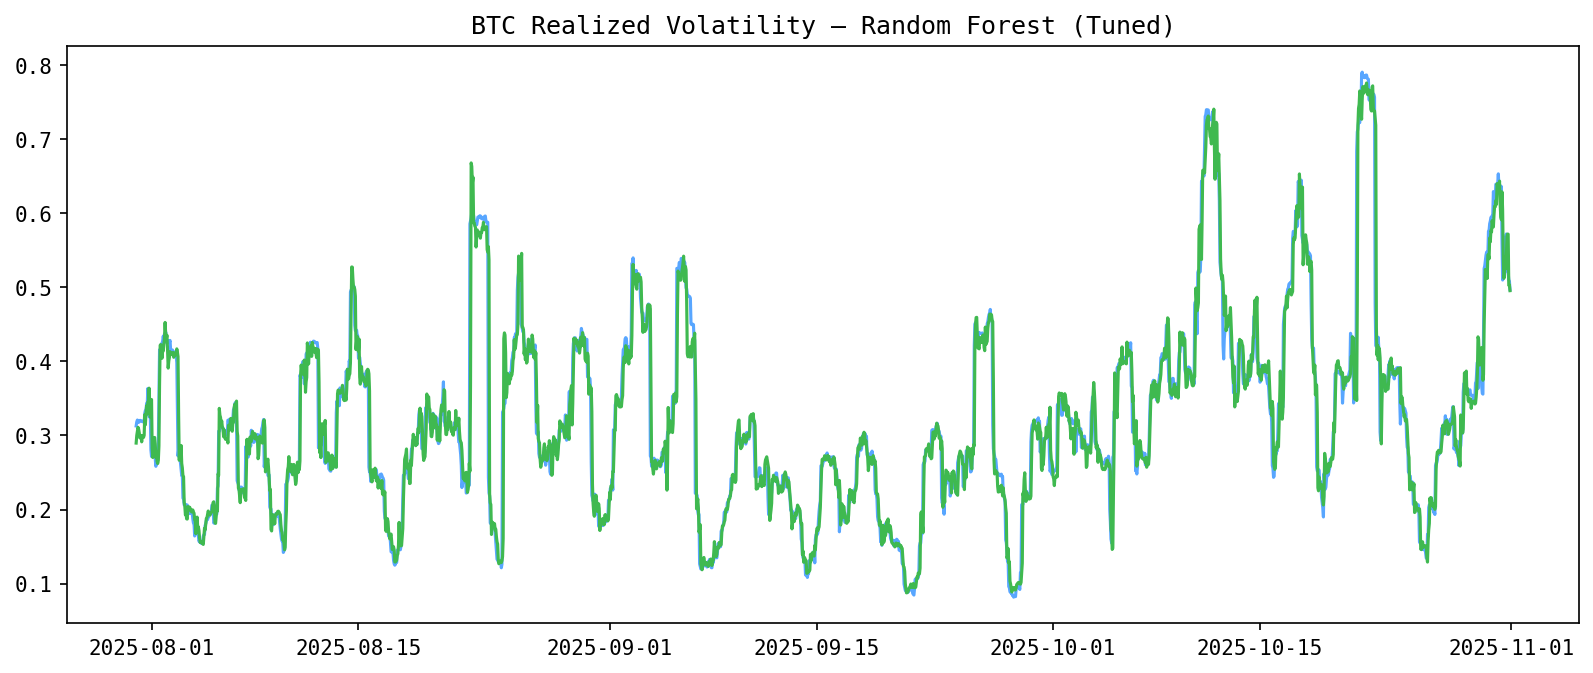

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/05_btc_rf_feature_importance.png


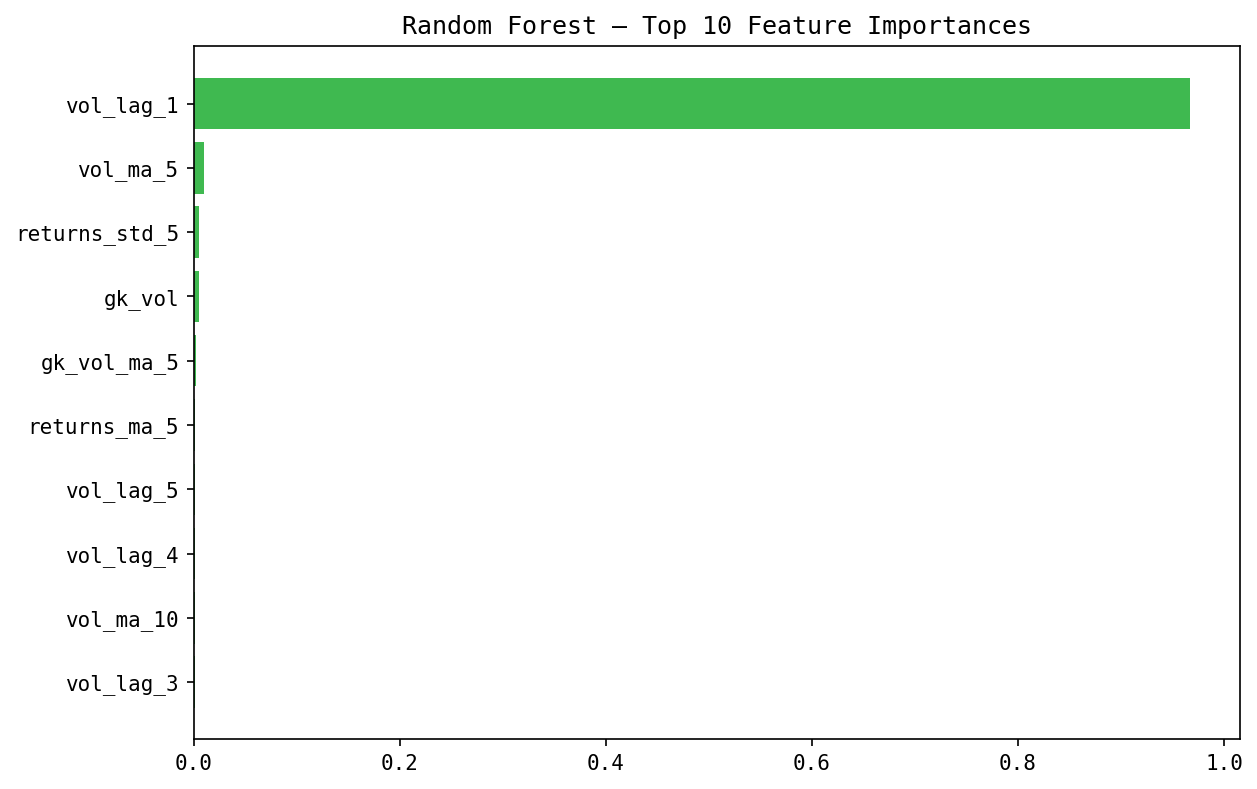

Best RF params: {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 5}  (CV RMSE=0.0460)
Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/06_btc_rf_timeseries.png


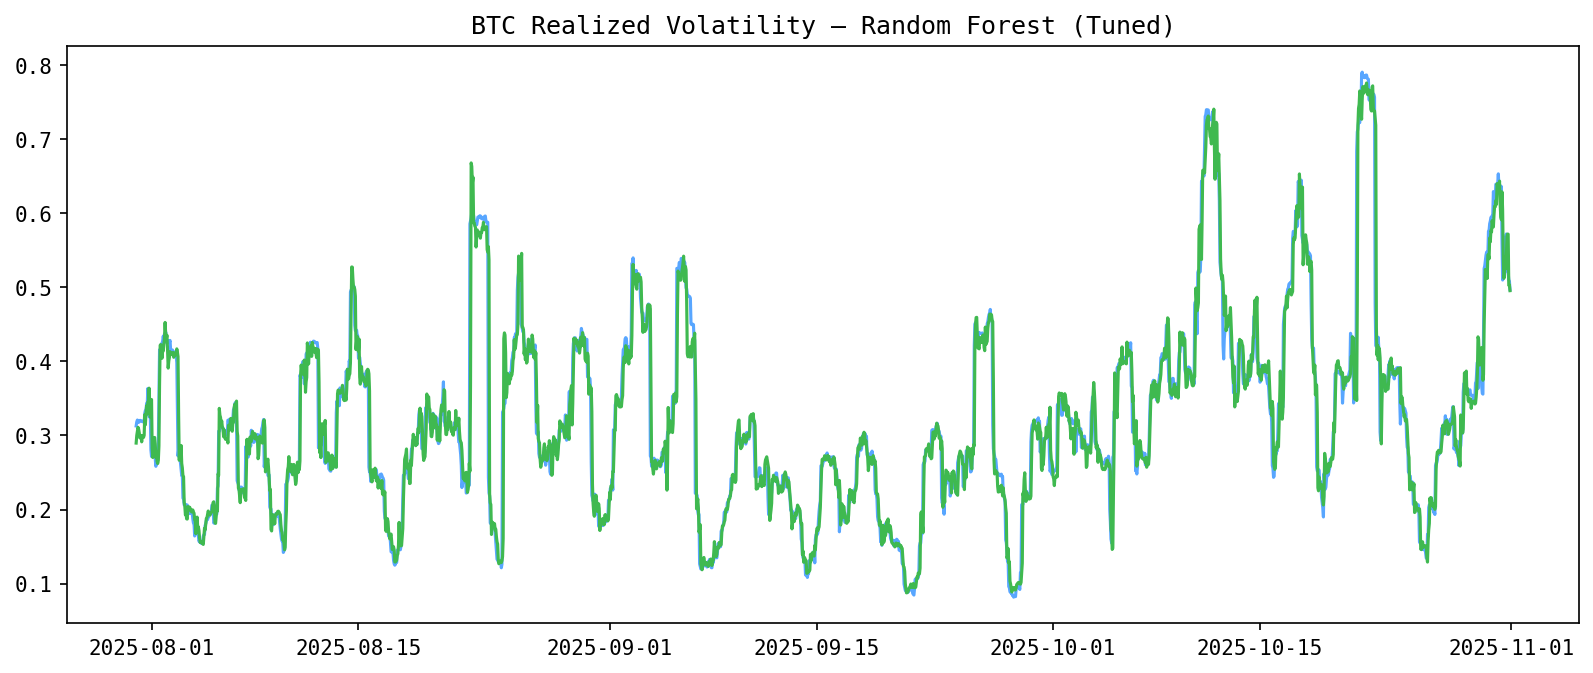

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/07_btc_rf_feature_importance.png


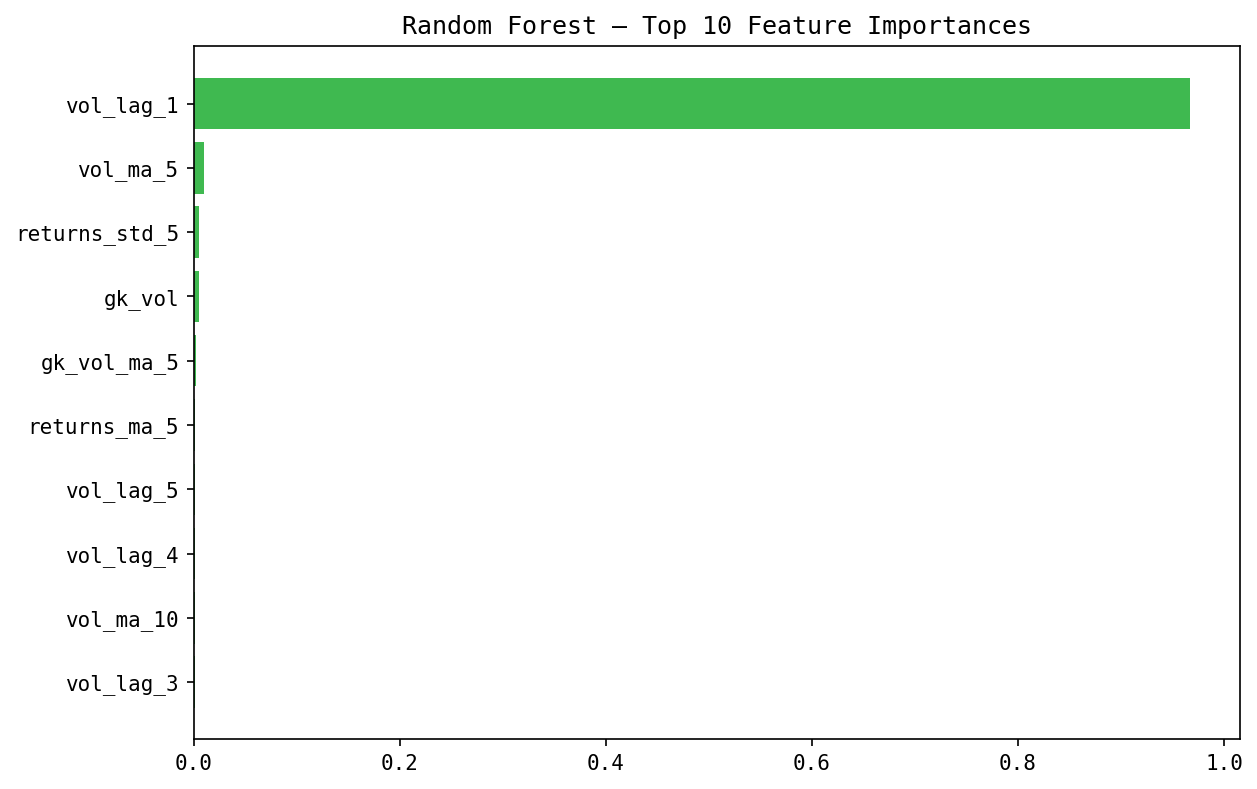

In [21]:
def blocked_purged_splits(n_samples, n_splits=5, purge=30):
    """
    Yields (train_idx, val_idx) for expanding-window blocked CV with a purge
    gap of `purge` observations removed from the end of train (right before
    val) to prevent leakage from rolling/lagged features.
    """
    fold_size = n_samples // (n_splits + 1)
    for i in range(1, n_splits + 1):
        train_end = fold_size * i
        val_start = train_end + purge
        val_end   = val_start + fold_size
        if val_end > n_samples:
            val_end = n_samples
        train_idx = np.arange(0, train_end - purge)
        val_idx   = np.arange(val_start, val_end)
        if len(val_idx) == 0:
            continue
        yield train_idx, val_idx


# --- RANDOM FOREST (tuned via blocked/purged CV) ---
from itertools import product

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [1, 5],
}

def grid_dicts(grid):
    keys = list(grid.keys())
    for combo in product(*grid.values()):
        yield dict(zip(keys, combo))

best_rf_params, best_rf_score = None, np.inf

for params in grid_dicts(rf_param_grid):
    fold_rmses = []
    for tr_idx, val_idx in blocked_purged_splits(len(X_train), n_splits=5, purge=30):
        X_tr_fold, y_tr_fold = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]

        rf_cv = RandomForestRegressor(random_state=SEED, n_jobs=-1, **params)
        rf_cv.fit(X_tr_fold, y_tr_fold)
        preds = rf_cv.predict(X_val_fold)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val_fold, preds)))

    mean_rmse = np.mean(fold_rmses)
    if mean_rmse < best_rf_score:
        best_rf_score, best_rf_params = mean_rmse, params

print(f"Best RF params: {best_rf_params}  (CV RMSE={best_rf_score:.4f})")

rf_model = RandomForestRegressor(random_state=SEED, n_jobs=-1, **best_rf_params)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rmse_rf, mae_rf, r2_rf = np.sqrt(mean_squared_error(y_test, rf_preds)), mean_absolute_error(y_test, rf_preds), r2_score(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index, y_test.values, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index, rf_preds, color=COLORS["rf"], label="Random Forest")
ax.set_title("BTC Realized Volatility — Random Forest (Tuned)")
save_and_show(fig, "btc_rf_timeseries")

rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(rf_imp.index, rf_imp.values, color=COLORS["rf"]); ax.set_title("Random Forest — Top 10 Feature Importances")
save_and_show(fig, "btc_rf_feature_importance")

# --- RANDOM FOREST (tuned via blocked/purged CV) ---
from itertools import product

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [1, 5],
}

def grid_dicts(grid):
    keys = list(grid.keys())
    for combo in product(*grid.values()):
        yield dict(zip(keys, combo))

best_rf_params, best_rf_score = None, np.inf

for params in grid_dicts(rf_param_grid):
    fold_rmses = []
    for tr_idx, val_idx in blocked_purged_splits(len(X_train), n_splits=5, purge=30):
        X_tr_fold, y_tr_fold = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]

        rf_cv = RandomForestRegressor(random_state=SEED, n_jobs=-1, **params)
        rf_cv.fit(X_tr_fold, y_tr_fold)
        preds = rf_cv.predict(X_val_fold)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val_fold, preds)))

    mean_rmse = np.mean(fold_rmses)
    if mean_rmse < best_rf_score:
        best_rf_score, best_rf_params = mean_rmse, params

print(f"Best RF params: {best_rf_params}  (CV RMSE={best_rf_score:.4f})")

# Refit on full training set with best params
rf_model = RandomForestRegressor(random_state=SEED, n_jobs=-1, **best_rf_params)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rmse_rf, mae_rf, r2_rf = np.sqrt(mean_squared_error(y_test, rf_preds)), mean_absolute_error(y_test, rf_preds), r2_score(y_test, rf_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index, y_test.values, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index, rf_preds, color=COLORS["rf"], label="Random Forest")
ax.set_title("BTC Realized Volatility — Random Forest (Tuned)")
save_and_show(fig, "btc_rf_timeseries")

rf_imp = pd.Series(rf_model.feature_importances_, index=X_train.columns).nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(rf_imp.index, rf_imp.values, color=COLORS["rf"]); ax.set_title("Random Forest — Top 10 Feature Importances")
save_and_show(fig, "btc_rf_feature_importance")

## LSTM

params={'units': 30, 'dropout': 0.2}  CV RMSE=0.0619
params={'units': 30, 'dropout': 0.3}  CV RMSE=0.0707
params={'units': 50, 'dropout': 0.2}  CV RMSE=0.0538
params={'units': 50, 'dropout': 0.3}  CV RMSE=0.0509

Best LSTM params: {'units': 50, 'dropout': 0.3}  (CV RMSE=0.0509)
Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/08_btc_lstm_timeseries.png


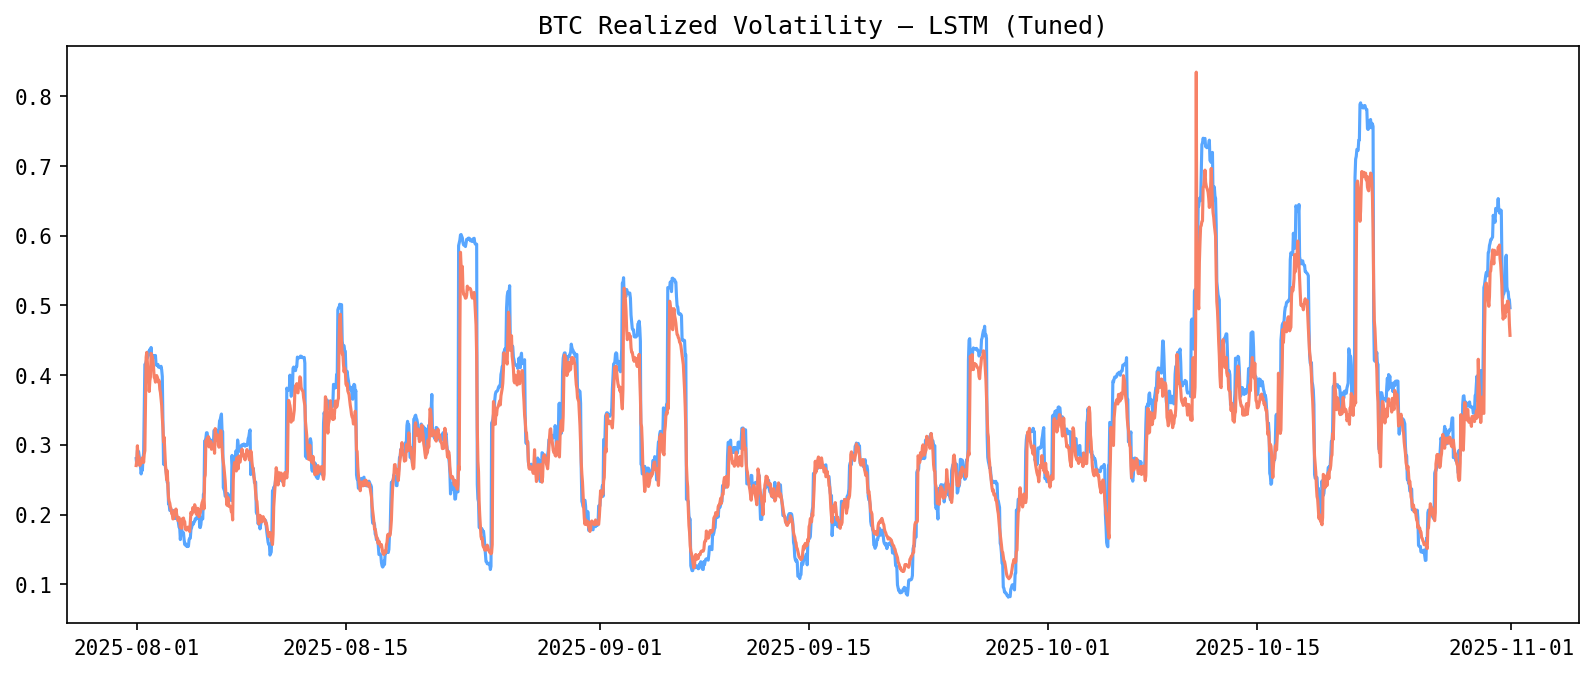

In [22]:
# --- LSTM (tuned via blocked/purged CV) ---
lstm_param_grid = {
    "units": [30, 50],
    "dropout": [0.2, 0.3],
}

CV_EPOCHS = 8  # cheaper proxy during search
FINAL_EPOCHS = 20

best_lstm_params, best_lstm_score = None, np.inf

for params in grid_dicts(lstm_param_grid):
    fold_rmses = []
    for tr_idx, val_idx in blocked_purged_splits(len(X_train), n_splits=5, purge=30):
        X_tr_fold, y_tr_fold = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]

        # Scale using train fold only (no leakage into val fold)
        sx_cv, sy_cv = MinMaxScaler(), MinMaxScaler()
        X_tr_sc = sx_cv.fit_transform(X_tr_fold)
        X_val_sc = sx_cv.transform(X_val_fold)
        y_tr_sc = sy_cv.fit_transform(y_tr_fold.values.reshape(-1, 1))
        y_val_sc = sy_cv.transform(y_val_fold.values.reshape(-1, 1))

        X_tr_seq, y_tr_seq = create_sequences(X_tr_sc, y_tr_sc, 24)
        X_val_seq, y_val_seq = create_sequences(X_val_sc, y_val_sc, 24)

        if len(X_val_seq) == 0:
            continue

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        lstm_cv = Sequential([
            Input(shape=(24, X_train.shape[1])),
            LSTM(params["units"], activation="tanh"),
            Dropout(params["dropout"]),
            Dense(25, activation="relu"),
            Dense(1)
        ])
        lstm_cv.compile(optimizer="adam", loss="mse")
        lstm_cv.fit(X_tr_seq, y_tr_seq, epochs=CV_EPOCHS, batch_size=32, verbose=0)

        preds_sc = lstm_cv.predict(X_val_seq, verbose=0)
        preds = sy_cv.inverse_transform(preds_sc).flatten()
        actual = sy_cv.inverse_transform(y_val_seq).flatten()
        fold_rmses.append(np.sqrt(mean_squared_error(actual, preds)))

    mean_rmse = np.mean(fold_rmses)
    print(f"params={params}  CV RMSE={mean_rmse:.4f}")
    if mean_rmse < best_lstm_score:
        best_lstm_score, best_lstm_params = mean_rmse, params

print(f"\nBest LSTM params: {best_lstm_params}  (CV RMSE={best_lstm_score:.4f})")

# Refit on full training set with best params and full epoch budget
scaler_x, scaler_y = MinMaxScaler(), MinMaxScaler()
X_tr_sc, X_te_sc = scaler_x.fit_transform(X_train), scaler_x.transform(X_test)
y_tr_sc, y_te_sc = scaler_y.fit_transform(y_train.values.reshape(-1, 1)), scaler_y.transform(y_test.values.reshape(-1, 1))
X_s, y_s = create_sequences(X_tr_sc, y_tr_sc, 24); X_ts, y_ts = create_sequences(X_te_sc, y_te_sc, 24)

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

lstm_model = Sequential([
    Input(shape=(24, X_train.shape[1])),
    LSTM(best_lstm_params["units"], activation="tanh"),
    Dropout(best_lstm_params["dropout"]),
    Dense(25, activation="relu"),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
history = lstm_model.fit(X_s, y_s, epochs=FINAL_EPOCHS, batch_size=32, validation_split=0.1, verbose=0)
lstm_preds = scaler_y.inverse_transform(lstm_model.predict(X_ts, verbose=0)).flatten()
y_test_lstm = scaler_y.inverse_transform(y_ts).flatten()
rmse_lstm, mae_lstm, r2_lstm = np.sqrt(mean_squared_error(y_test_lstm, lstm_preds)), mean_absolute_error(y_test_lstm, lstm_preds), r2_score(y_test_lstm, lstm_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index[24:], y_test_lstm, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index[24:], lstm_preds, color=COLORS["lstm"], label="LSTM (Tuned)")
ax.set_title("BTC Realized Volatility — LSTM (Tuned)")
save_and_show(fig, "btc_lstm_timeseries")

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/13_btc_lstm_residuals.png


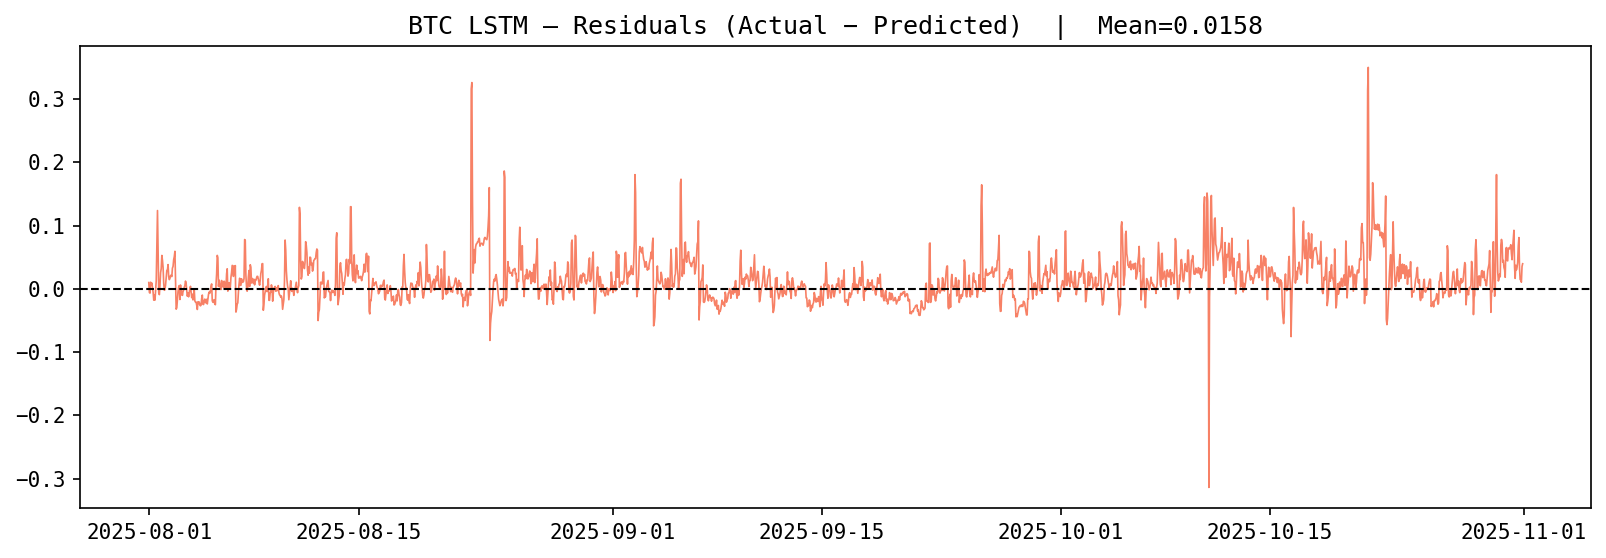

Residual mean: 0.0158  (positive = model under-predicts on average)
Residual std:  0.0353


In [25]:
# --- LSTM Residual Plot (Actual - Predicted) ---
lstm_residuals = y_test_lstm - lstm_preds

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(y_test.index[24:], lstm_residuals, color=COLORS["lstm"], linewidth=0.8)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title(f"BTC LSTM — Residuals (Actual − Predicted)  |  Mean={lstm_residuals.mean():.4f}")
save_and_show(fig, "btc_lstm_residuals")

print(f"Residual mean: {lstm_residuals.mean():.4f}  (positive = model under-predicts on average)")
print(f"Residual std:  {lstm_residuals.std():.4f}")

## XGBoost

params={'max_depth': 4, 'learning_rate': 0.03}  CV RMSE=0.0455
params={'max_depth': 4, 'learning_rate': 0.05}  CV RMSE=0.0455
params={'max_depth': 4, 'learning_rate': 0.1}  CV RMSE=0.0458
params={'max_depth': 6, 'learning_rate': 0.03}  CV RMSE=0.0464
params={'max_depth': 6, 'learning_rate': 0.05}  CV RMSE=0.0465
params={'max_depth': 6, 'learning_rate': 0.1}  CV RMSE=0.0465
params={'max_depth': 8, 'learning_rate': 0.03}  CV RMSE=0.0468
params={'max_depth': 8, 'learning_rate': 0.05}  CV RMSE=0.0467
params={'max_depth': 8, 'learning_rate': 0.1}  CV RMSE=0.0471

Best XGBoost params: {'max_depth': 4, 'learning_rate': 0.05}  (CV RMSE=0.0455)
Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/09_btc_xgb_timeseries.png


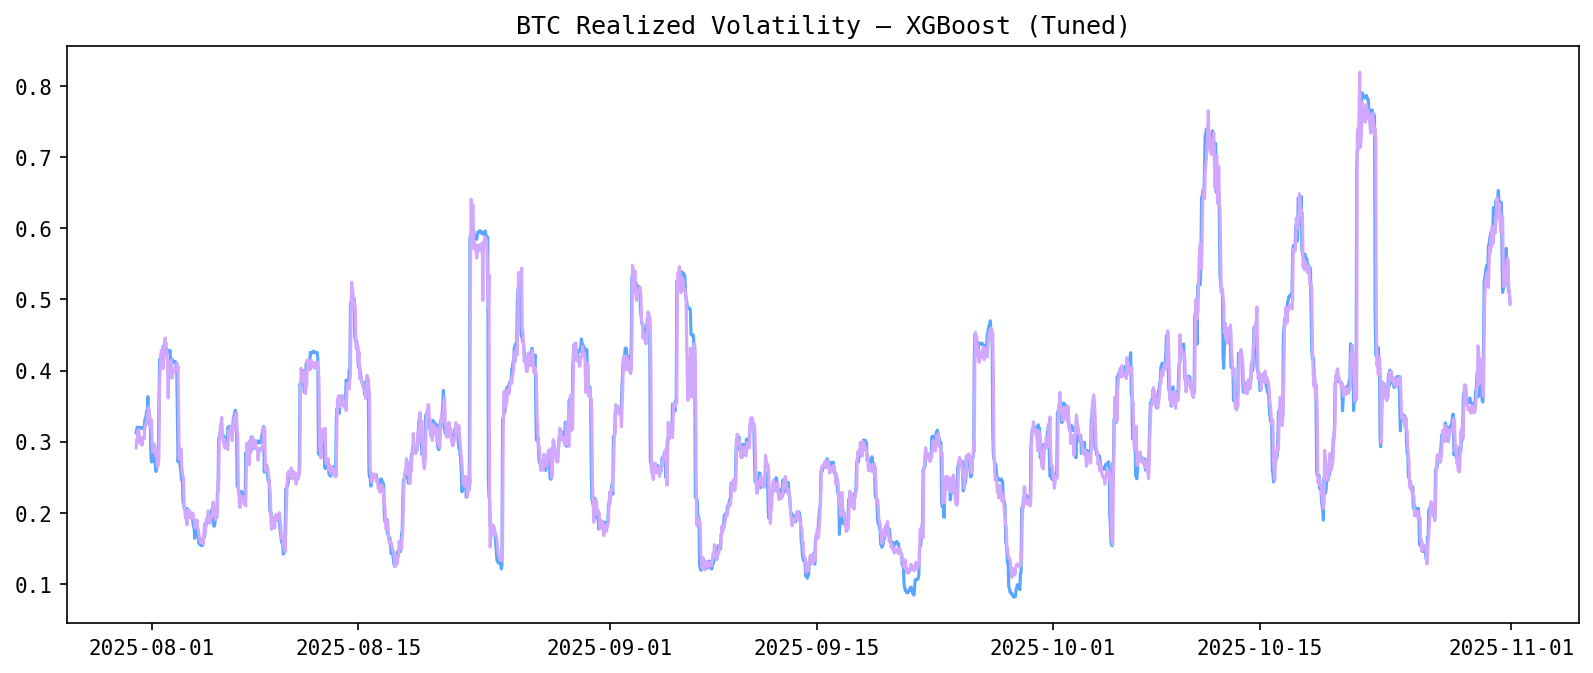

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/10_btc_xgb_feature_importance.png


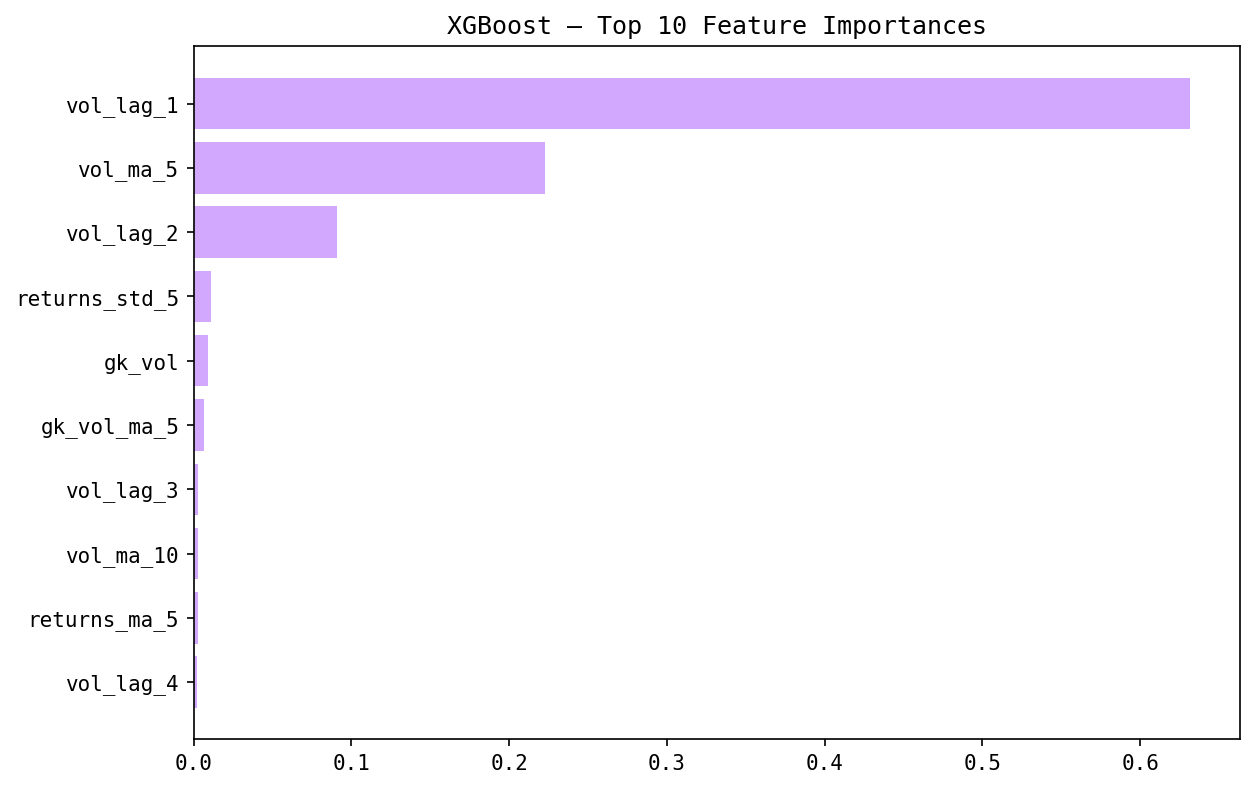

In [23]:
# --- XGBOOST (tuned via blocked/purged CV, no test-set leakage) ---
xgb_param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
}

best_xgb_params, best_xgb_score = None, np.inf

for params in grid_dicts(xgb_param_grid):
    fold_rmses = []
    for tr_idx, val_idx in blocked_purged_splits(len(X_train), n_splits=5, purge=30):
        X_tr_fold, y_tr_fold = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
        X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]

        xgb_cv = xgb.XGBRegressor(
            n_estimators=1000, subsample=0.8, colsample_bytree=0.8,
            objective="reg:squarederror", tree_method="hist",
            early_stopping_rounds=50, random_state=SEED, verbosity=0,
            **params
        )
        # eval_set here is the CV val fold, never the true test set
        xgb_cv.fit(X_tr_fold, y_tr_fold, eval_set=[(X_val_fold, y_val_fold)], verbose=False)
        preds = xgb_cv.predict(X_val_fold)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val_fold, preds)))

    mean_rmse = np.mean(fold_rmses)
    print(f"params={params}  CV RMSE={mean_rmse:.4f}")
    if mean_rmse < best_xgb_score:
        best_xgb_score, best_xgb_params = mean_rmse, params

print(f"\nBest XGBoost params: {best_xgb_params}  (CV RMSE={best_xgb_score:.4f})")

# --- Final fit: early stopping validated on a held-out slice of TRAIN, not X_test ---
n_final_val = int(len(X_train) * 0.1)  # last 10% of train, chronologically, as ES validation
X_fit, X_es_val = X_train.iloc[:-n_final_val], X_train.iloc[-n_final_val:]
y_fit, y_es_val = y_train.iloc[:-n_final_val], y_train.iloc[-n_final_val:]

xgb_model = xgb.XGBRegressor(
    n_estimators=1000, subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror", tree_method="hist",
    early_stopping_rounds=50, random_state=SEED,
    **best_xgb_params
)
xgb_model.fit(X_fit, y_fit, eval_set=[(X_es_val, y_es_val)], verbose=False)

xgb_preds = xgb_model.predict(X_test)
rmse_xgb, mae_xgb, r2_xgb = np.sqrt(mean_squared_error(y_test, xgb_preds)), mean_absolute_error(y_test, xgb_preds), r2_score(y_test, xgb_preds)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_test.index, y_test.values, color=COLORS["actual"], label="Actual")
ax.plot(y_test.index, xgb_preds, color=COLORS["xgb"], label="XGBoost")
ax.set_title("BTC Realized Volatility — XGBoost (Tuned)")
save_and_show(fig, "btc_xgb_timeseries")

xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train.columns).nlargest(10).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(xgb_imp.index, xgb_imp.values, color=COLORS["xgb"]); ax.set_title("XGBoost — Top 10 Feature Importances")
save_and_show(fig, "btc_xgb_feature_importance")

## Summary For BTC and ETH

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/11_btc_model_comparison.png


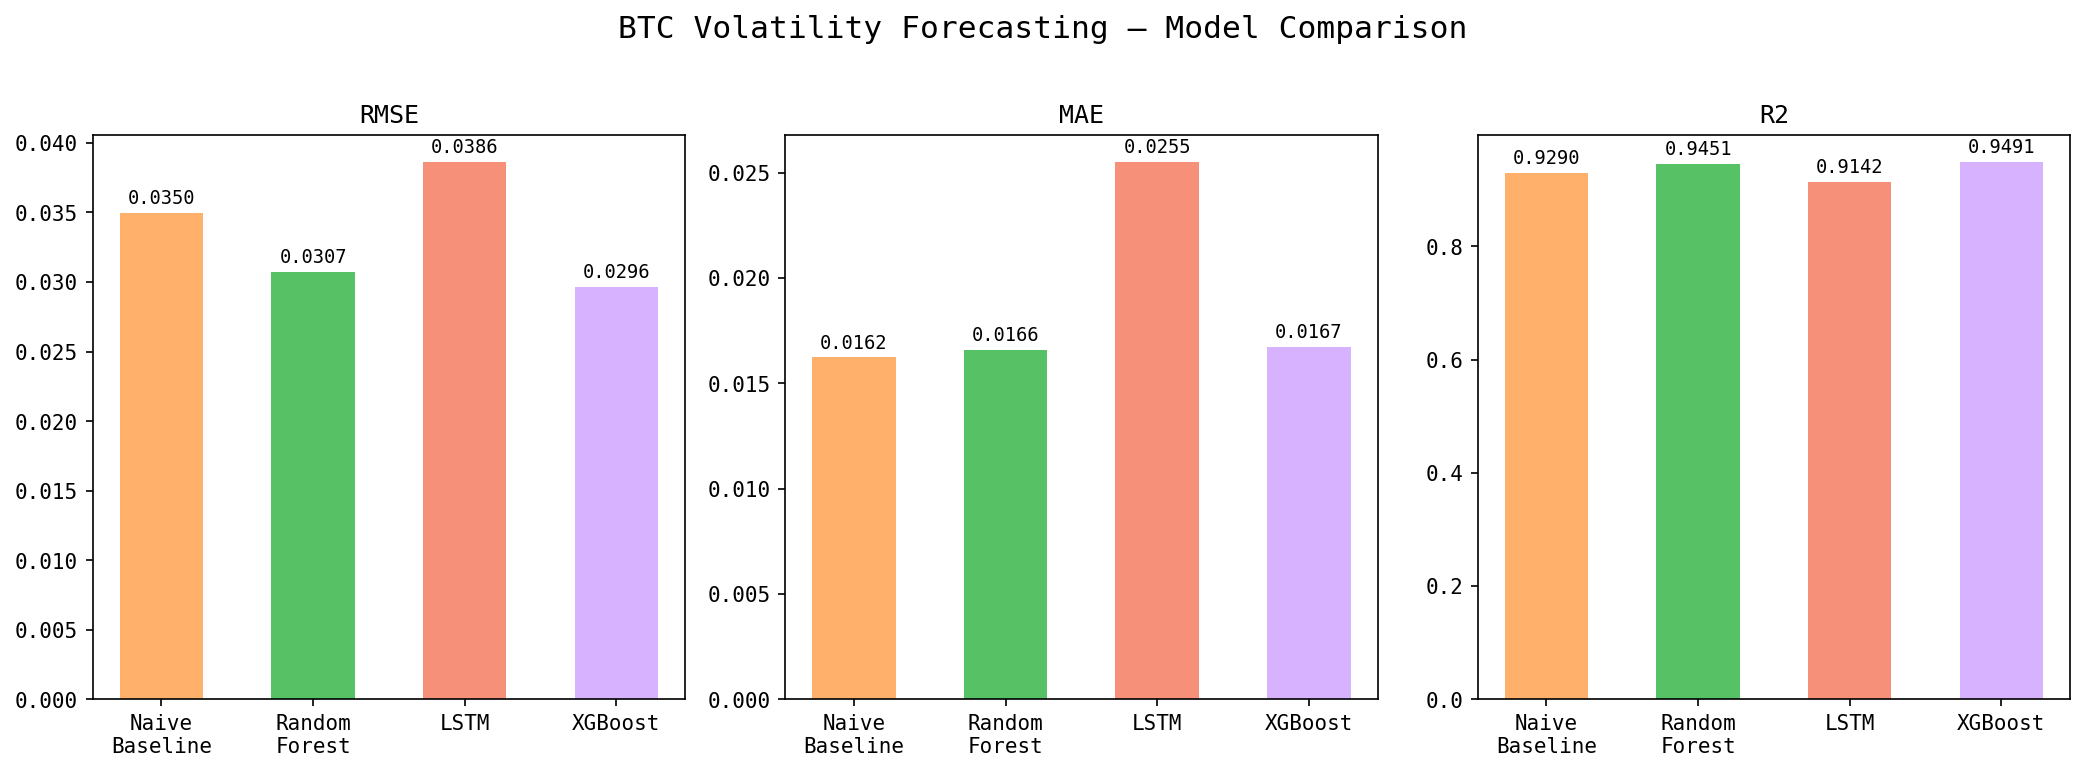

[*********************100%***********************]  1 of 1 completed


Processing ETH-USD comparison...



/opt/anaconda3/envs/my_env_311/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/12_eth_model_comparison.png


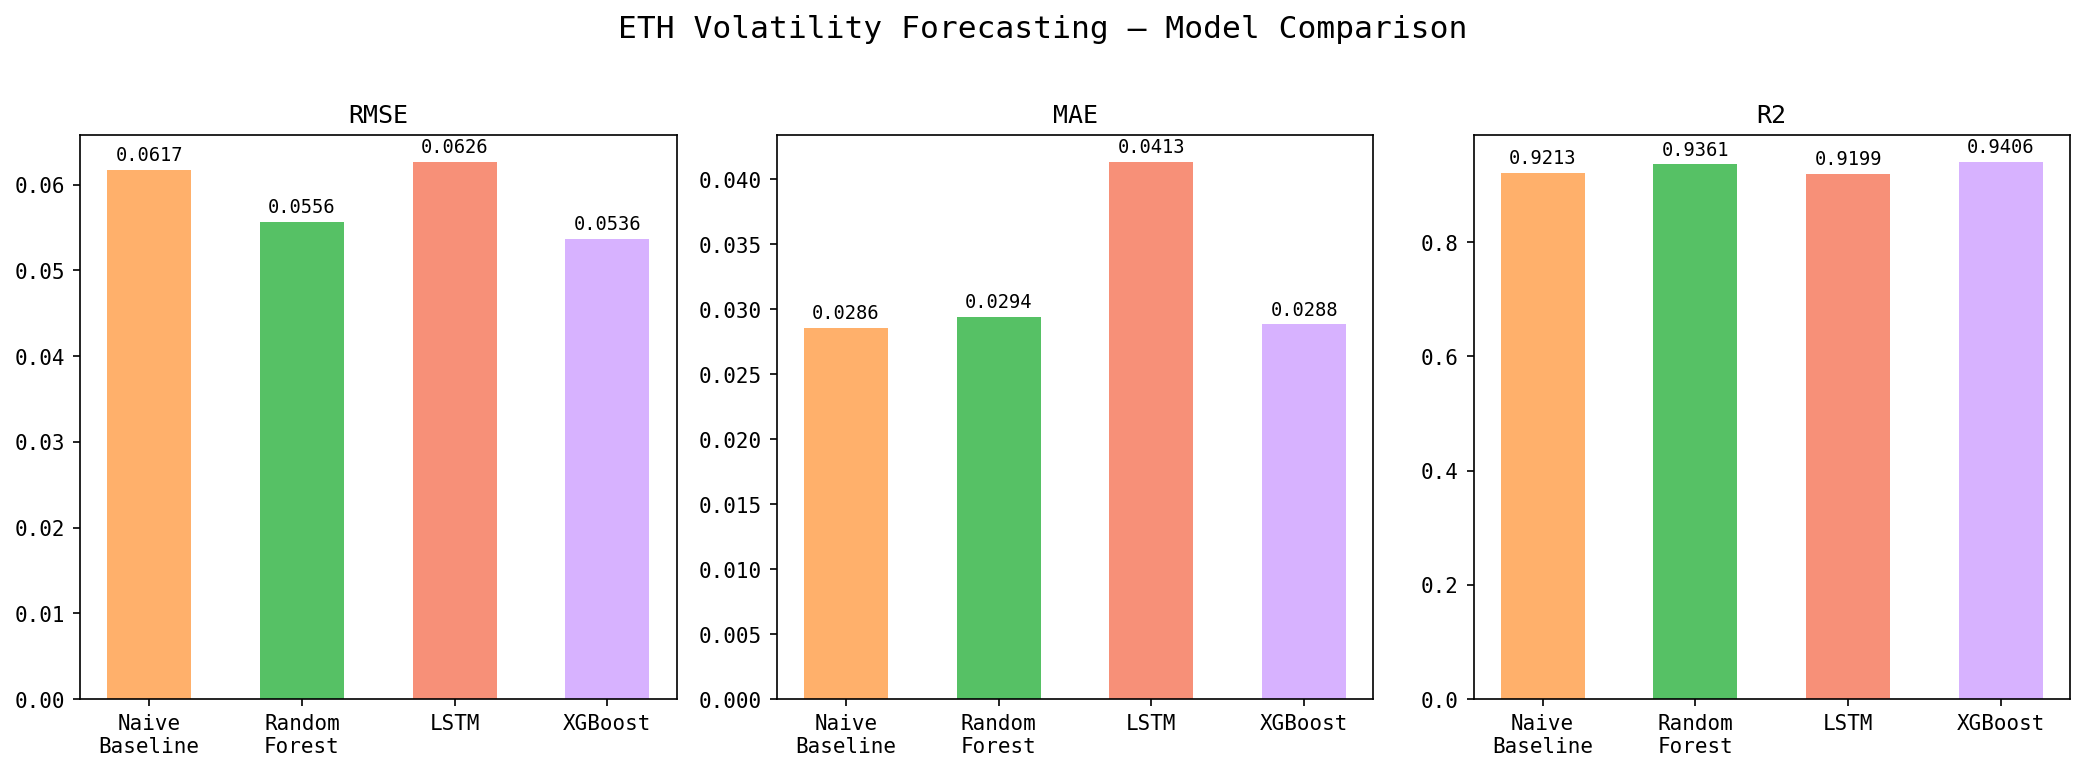


All charts saved as transparent PNGs in: /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs


In [24]:
# BTC Summary Plot
results_btc = {"Naive\nBaseline": {"rmse": rmse_naive, "mae": mae_naive, "r2": r2_naive}, "Random\nForest": {"rmse": rmse_rf, "mae": mae_rf, "r2": r2_rf}, "LSTM": {"rmse": rmse_lstm, "mae": mae_lstm, "r2": r2_lstm}, "XGBoost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb}}
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("BTC Volatility Forecasting — Model Comparison", fontsize=15, y=1.02)
for i, metric in enumerate(["rmse", "mae", "r2"]):
    vals = [results_btc[m][metric] for m in results_btc]
    bars = axes[i].bar(results_btc.keys(), vals, color=[COLORS["naive"], COLORS["rf"], COLORS["lstm"], COLORS["xgb"]], alpha=0.88, width=0.55)
    axes[i].set_title(metric.upper())
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=9, color=COLORS["accent"])
plt.tight_layout()
save_and_show(fig, "btc_model_comparison")

# =============================================================================
# 3. ETH-USD SECTION (COMPARISON GRAPH ONLY)
# =============================================================================
print("\nProcessing ETH-USD comparison...")
eth = yf.download("ETH-USD", start="2024-09-01", end="2025-11-01", interval="1h", auto_adjust=True)
eth.columns = eth.columns.get_level_values(0)
eth_train = add_vol_columns(eth.iloc[:split_idx]); eth_test = add_vol_columns(eth.iloc[split_idx:])
EX_tr, Ey_tr = make_xy(eth_train); EX_te, Ey_te = make_xy(eth_test)

# Naive
en_p = EX_te["vol_lag_1"]

# RF
erf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=SEED).fit(EX_tr, Ey_tr)

# LSTM
esx, esy = MinMaxScaler(), MinMaxScaler()
EX_tr_s, EX_te_s = esx.fit_transform(EX_tr), esx.transform(EX_te)
Ey_tr_s = esy.fit_transform(Ey_tr.values.reshape(-1,1))
EX_s, Ey_s = create_sequences(EX_tr_s, Ey_tr_s, 24); EX_ts, Ey_ts = create_sequences(EX_te_s, esy.transform(Ey_te.values.reshape(-1,1)), 24)

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

em = Sequential([LSTM(50, input_shape=(24, EX_tr.shape[1])), Dense(1)])
em.compile(optimizer="adam", loss="mse")
em.fit(EX_s, Ey_s, epochs=15, verbose=0)
em_p = esy.inverse_transform(em.predict(EX_ts, verbose=0)).flatten()

# XGB
exg = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, early_stopping_rounds=50, random_state=SEED)
exg.fit(EX_tr, Ey_tr, eval_set=[(EX_te, Ey_te)], verbose=False)

results_eth = {
    "Naive\nBaseline": {"rmse": np.sqrt(mean_squared_error(Ey_te, en_p)), "mae": mean_absolute_error(Ey_te, en_p), "r2": r2_score(Ey_te, en_p)},
    "Random\nForest":  {"rmse": np.sqrt(mean_squared_error(Ey_te, erf.predict(EX_te))), "mae": mean_absolute_error(Ey_te, erf.predict(EX_te)), "r2": r2_score(Ey_te, erf.predict(EX_te))},
    "LSTM":            {"rmse": np.sqrt(mean_squared_error(esy.inverse_transform(Ey_ts).flatten(), em_p)), "mae": mean_absolute_error(esy.inverse_transform(Ey_ts).flatten(), em_p), "r2": r2_score(esy.inverse_transform(Ey_ts).flatten(), em_p)},
    "XGBoost":         {"rmse": np.sqrt(mean_squared_error(Ey_te, exg.predict(EX_te))), "mae": mean_absolute_error(Ey_te, exg.predict(EX_te)), "r2": r2_score(Ey_te, exg.predict(EX_te))},
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("ETH Volatility Forecasting — Model Comparison", fontsize=15, y=1.02)
for i, metric in enumerate(["rmse", "mae", "r2"]):
    vals = [results_eth[m][metric] for m in results_eth]
    bars = axes[i].bar(results_eth.keys(), vals, color=[COLORS["naive"], COLORS["rf"], COLORS["lstm"], COLORS["xgb"]], alpha=0.88, width=0.55)
    axes[i].set_title(metric.upper())
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=9, color=COLORS["accent"])
plt.tight_layout()
save_and_show(fig, "eth_model_comparison")

print(f"\nAll charts saved as transparent PNGs in: {OUT_DIR}")

# Extended Stacking Model With RIDGE Meta-Learner


  BUILDING STACKING ENSEMBLE (using tuned base models)
--- Fold 1 --- train: 1288  val: 1318
--- Fold 2 --- train: 2606  val: 1318
--- Fold 3 --- train: 3924  val: 1318
--- Fold 4 --- train: 5242  val: 1318
--- Fold 5 --- train: 6560  val: 1291

OOF generation complete.
Meta-training set shape: (6563, 7)
alpha=0.01   CV RMSE=0.0378
alpha=0.1    CV RMSE=0.0377
alpha=1.0    CV RMSE=0.0372
alpha=5.0    CV RMSE=0.0369
alpha=10.0   CV RMSE=0.0371
alpha=50.0   CV RMSE=0.0419

Best Ridge alpha: 5.0  (CV RMSE=0.0369)

--- Stacking Ensemble (Ridge meta-learner, tuned) ---
RMSE : 0.0305  |  MAE : 0.0162  |  R² : 0.9466

Meta-learner weights:
  naive        +0.1940
  garch        +0.1938
  rf           +0.0761
  xgb          +0.0914
  lstm         +0.2261
  vol_lag_1    +0.1940
  gk_vol       +0.0689
  intercept    -0.0067
Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/29_btc_stacking_timeseries.png


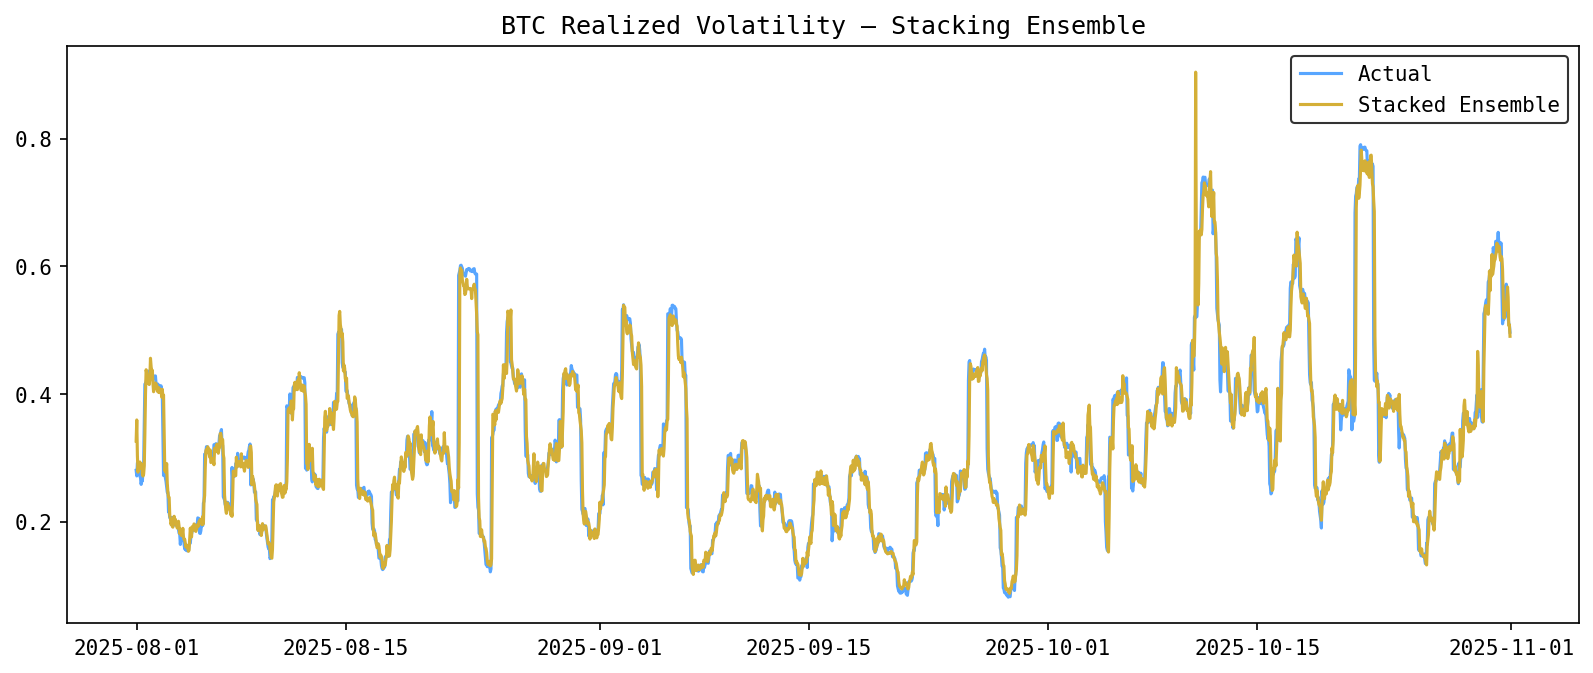

Saved transparent chart -> /Users/oliverhoyrup/Desktop/Økonomi/8. sem (Berlin)/DEDA/pngs/30_btc_full_comparison_with_stacking.png


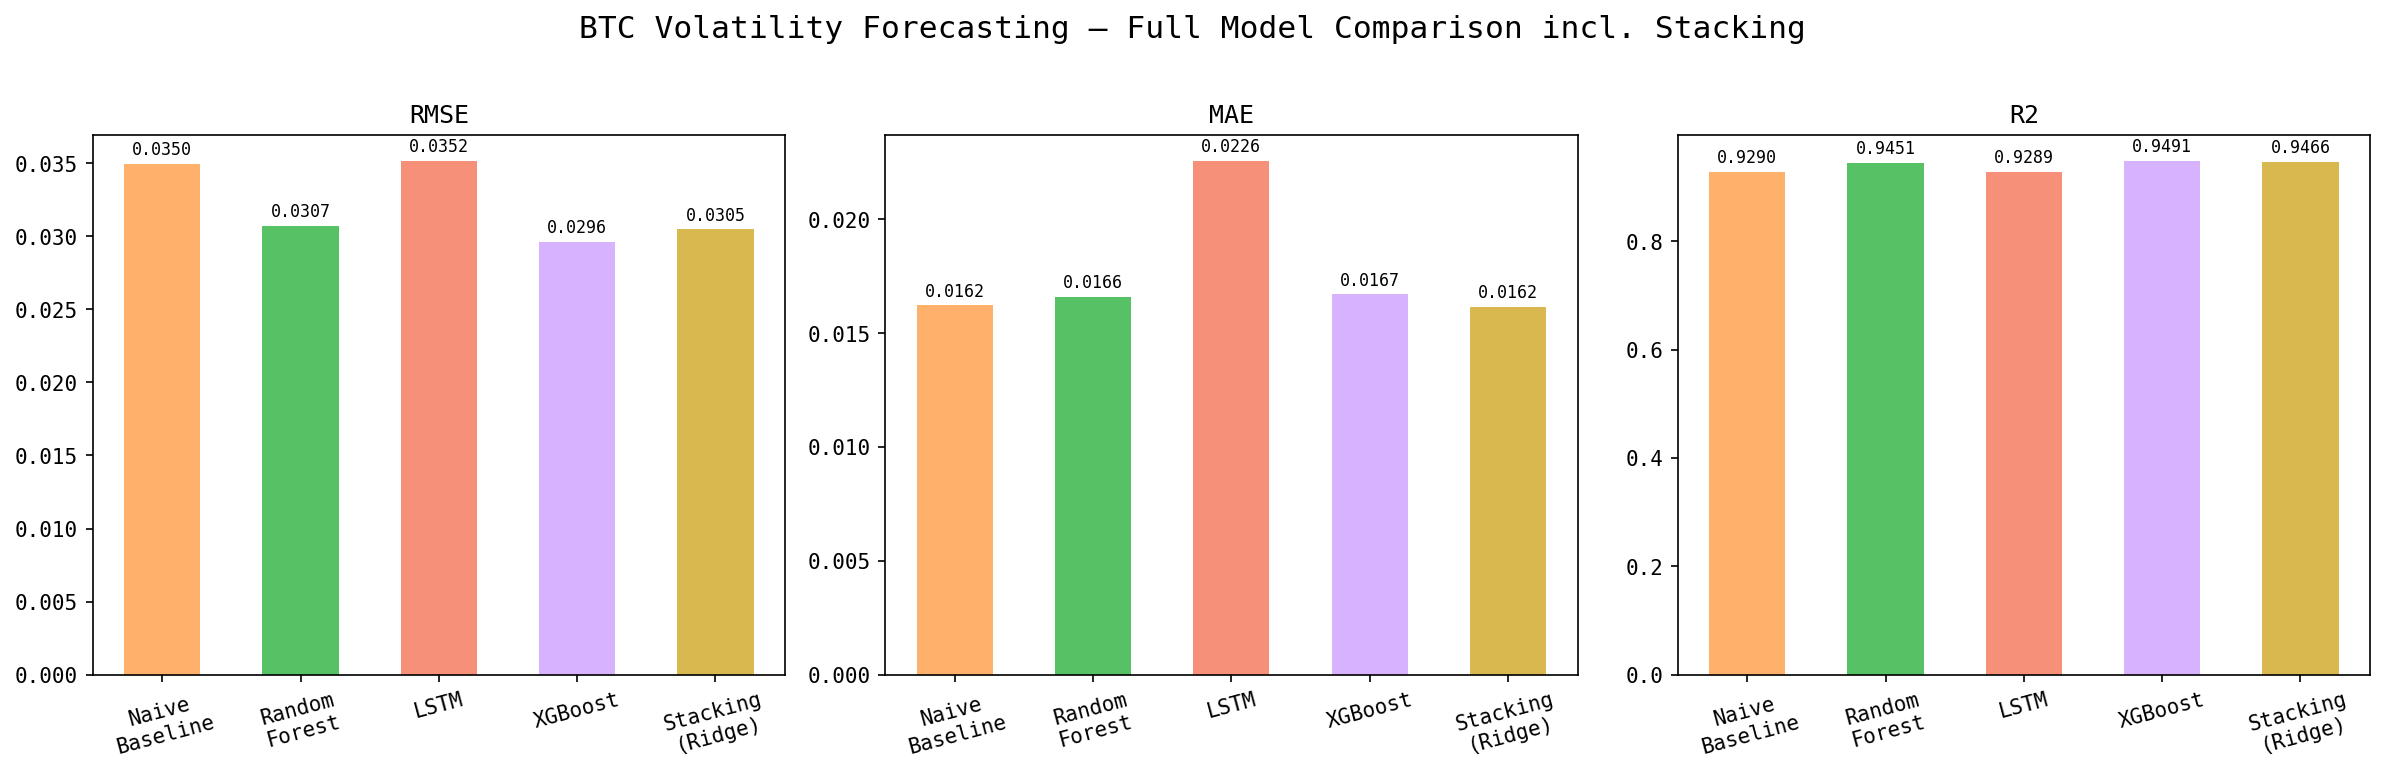


  FINAL RESULTS — BTC-USD
Naive Baseline       RMSE=0.0350  MAE=0.0162  R²=0.9290
Random Forest        RMSE=0.0307  MAE=0.0166  R²=0.9451
LSTM                 RMSE=0.0352  MAE=0.0226  R²=0.9289
XGBoost              RMSE=0.0296  MAE=0.0167  R²=0.9491
Stacking (Ridge)     RMSE=0.0305  MAE=0.0162  R²=0.9466


In [17]:
# =============================================================================
# 4. STACKING ENSEMBLE (Naive + GARCH + RF + LSTM + XGBoost -> Ridge meta-learner)
# =============================================================================
from sklearn.linear_model import Ridge
from arch import arch_model
from tensorflow.keras.layers import Input

print("\n" + "="*60)
print("  BUILDING STACKING ENSEMBLE (using tuned base models)")
print("="*60)

# ── 4.1  Blocked / Purged Time-Series CV ─────────────────────────────────────
def blocked_purged_splits(n_samples, n_splits=5, purge=30):
    fold_size = n_samples // (n_splits + 1)
    for i in range(1, n_splits + 1):
        train_end = fold_size * i
        val_start = train_end + purge
        val_end   = val_start + fold_size
        if val_end > n_samples:
            val_end = n_samples
        train_idx = np.arange(0, train_end - purge)
        val_idx   = np.arange(val_start, val_end)
        if len(val_idx) == 0:
            continue
        yield train_idx, val_idx


# ── 4.2  Generate out-of-fold (OOF) base predictions on TRAIN set ───────────
n_train = len(X_train)
oof_naive = np.full(n_train, np.nan)
oof_rf    = np.full(n_train, np.nan)
oof_xgb   = np.full(n_train, np.nan)
oof_lstm  = np.full(n_train, np.nan)
oof_garch = np.full(n_train, np.nan)

train_returns_full = btc_train["log_returns"].values

for fold_i, (tr_idx, val_idx) in enumerate(blocked_purged_splits(n_train, n_splits=5, purge=30)):
    print(f"--- Fold {fold_i+1} --- train: {len(tr_idx)}  val: {len(val_idx)}")

    X_tr_fold, y_tr_fold = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    X_val_fold           = X_train.iloc[val_idx]

    # Naive
    oof_naive[val_idx] = X_val_fold["vol_lag_1"].values

    # Random Forest — tuned params
    rf_fold = RandomForestRegressor(random_state=SEED, n_jobs=-1, **best_rf_params)
    rf_fold.fit(X_tr_fold, y_tr_fold)
    oof_rf[val_idx] = rf_fold.predict(X_val_fold)

    # XGBoost — tuned params
    xgb_fold = xgb.XGBRegressor(n_estimators=300, subsample=0.8, colsample_bytree=0.8,
                                objective="reg:squarederror", tree_method="hist",
                                random_state=SEED, verbosity=0, **best_xgb_params)
    xgb_fold.fit(X_tr_fold, y_tr_fold)
    oof_xgb[val_idx] = xgb_fold.predict(X_val_fold)

    # GARCH(1,1)
    try:
        ret_tr = train_returns_full[tr_idx] * 100
        ret_full_fold = np.concatenate([ret_tr, train_returns_full[val_idx] * 100])
        g_fit = arch_model(ret_tr, vol="Garch", p=1, q=1, mean="Zero", dist="normal").fit(disp="off")
        g_full = arch_model(ret_full_fold, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
        g_fixed = g_full.fix(g_fit.params)
        fc = g_fixed.forecast(horizon=1, reindex=True)
        garch_fold_preds = np.sqrt(fc.variance.values.flatten()[len(ret_tr):]) / 100 * ANNUALISE
        oof_garch[val_idx] = garch_fold_preds[:len(val_idx)]
    except Exception:
        oof_garch[val_idx] = X_val_fold["vol_lag_1"].values

    # LSTM — tuned params
    scaler_x_fold, scaler_y_fold = MinMaxScaler(), MinMaxScaler()
    X_tr_sc = scaler_x_fold.fit_transform(X_tr_fold)
    X_val_sc = scaler_x_fold.transform(X_val_fold)
    y_tr_sc = scaler_y_fold.fit_transform(y_tr_fold.values.reshape(-1, 1))

    X_tr_seq, y_tr_seq = create_sequences(X_tr_sc, y_tr_sc, window=24)

    if len(X_val_sc) > 24:
        X_val_seq, _ = create_sequences(X_val_sc, np.zeros((len(X_val_sc), 1)), window=24)

        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)

        lstm_fold = Sequential([
            Input(shape=(24, X_train.shape[1])),
            LSTM(best_lstm_params["units"], activation="tanh"),
            Dropout(best_lstm_params["dropout"]),
            Dense(25, activation="relu"),
            Dense(1)
        ])
        lstm_fold.compile(optimizer="adam", loss="mse")
        lstm_fold.fit(X_tr_seq, y_tr_seq, epochs=10, batch_size=32, verbose=0)

        preds_sc = lstm_fold.predict(X_val_seq, verbose=0)
        preds = scaler_y_fold.inverse_transform(preds_sc).flatten()
        oof_lstm[val_idx[24:]] = preds

print("\nOOF generation complete.")

# ── 4.3  Build meta-training set ─────────────────────────────────────────────
meta_train_df = pd.DataFrame({
    "naive": oof_naive,
    "garch": oof_garch,
    "rf":    oof_rf,
    "xgb":   oof_xgb,
    "lstm":  oof_lstm,
}, index=X_train.index)

for col in ["garch", "rf", "xgb", "lstm"]:
    meta_train_df[col] = meta_train_df[col].fillna(meta_train_df["naive"])

meta_train_df["vol_lag_1"] = X_train["vol_lag_1"].values
meta_train_df["gk_vol"]    = X_train["gk_vol"].values
meta_train_df["target"]    = y_train.values

meta_train_clean = meta_train_df.dropna()
X_meta_train = meta_train_clean.drop(columns="target")
y_meta_train = meta_train_clean["target"]

print(f"Meta-training set shape: {X_meta_train.shape}")

# ── 4.4  Base model predictions on TEST set — reusing already-tuned models ──
train_ret_scaled = btc_train["log_returns"].values * 100
garch_full_fit = arch_model(train_ret_scaled, vol="Garch", p=1, q=1,
                            mean="Zero", dist="normal").fit(disp="off")

full_ret_concat = np.concatenate([train_ret_scaled, btc_test["log_returns"].values * 100])
garch_test_spec = arch_model(full_ret_concat, vol="Garch", p=1, q=1, mean="Zero", dist="normal")
garch_test_fixed = garch_test_spec.fix(garch_full_fit.params)
fc_test = garch_test_fixed.forecast(horizon=1, reindex=True)
garch_test_preds_full = (
    np.sqrt(fc_test.variance.values.flatten()[len(train_ret_scaled):]) / 100 * ANNUALISE
)
garch_test_series = pd.Series(
    garch_test_preds_full,
    index=btc_test["log_returns"].index[:len(garch_test_preds_full)]
).reindex(y_test.index)

rf_test_preds  = rf_model.predict(X_test)
xgb_test_preds = xgb_model.predict(X_test)

# ── 4.5  Build meta-test set ─────────────────────────────────────────────────
lstm_index = y_test.index[24:]

meta_test_df = pd.DataFrame({
    "naive": naive_preds.reindex(lstm_index).values,
    "garch": garch_test_series.reindex(lstm_index).values,
    "rf":    pd.Series(rf_test_preds, index=y_test.index).reindex(lstm_index).values,
    "xgb":   pd.Series(xgb_test_preds, index=y_test.index).reindex(lstm_index).values,
    "lstm":  lstm_preds,
    "vol_lag_1": X_test["vol_lag_1"].reindex(lstm_index).values,
    "gk_vol":    X_test["gk_vol"].reindex(lstm_index).values,
}, index=lstm_index)

for col in meta_test_df.columns:
    meta_test_df[col] = meta_test_df[col].fillna(meta_test_df["naive"])

y_meta_test = y_test.reindex(lstm_index)

# ── 4.6  Train meta-learner (Ridge, tuned alpha, non-negative weights) ──────
ridge_alphas = [0.01, 0.1, 1.0, 5.0, 10.0, 50.0]
best_alpha, best_alpha_score = None, np.inf

n_meta = len(X_meta_train)
for alpha in ridge_alphas:
    fold_rmses = []
    for tr_idx, val_idx in blocked_purged_splits(n_meta, n_splits=5, purge=5):
        r_cv = Ridge(alpha=alpha, positive=True)
        r_cv.fit(X_meta_train.iloc[tr_idx], y_meta_train.iloc[tr_idx])
        preds = r_cv.predict(X_meta_train.iloc[val_idx])
        fold_rmses.append(np.sqrt(mean_squared_error(y_meta_train.iloc[val_idx], preds)))
    mean_rmse = np.mean(fold_rmses)
    print(f"alpha={alpha:<6} CV RMSE={mean_rmse:.4f}")
    if mean_rmse < best_alpha_score:
        best_alpha_score, best_alpha = mean_rmse, alpha

print(f"\nBest Ridge alpha: {best_alpha}  (CV RMSE={best_alpha_score:.4f})")

meta_model = Ridge(alpha=best_alpha, positive=True)
meta_model.fit(X_meta_train, y_meta_train)

if X_meta_train.shape[1] != meta_test_df.shape[1]:
    meta_test_df = meta_test_df[X_meta_train.columns]

stack_preds = meta_model.predict(meta_test_df)

rmse_stack = np.sqrt(mean_squared_error(y_meta_test, stack_preds))
mae_stack  = mean_absolute_error(y_meta_test, stack_preds)
r2_stack   = r2_score(y_meta_test, stack_preds)

print(f"\n--- Stacking Ensemble (Ridge meta-learner, tuned) ---")
print(f"RMSE : {rmse_stack:.4f}  |  MAE : {mae_stack:.4f}  |  R² : {r2_stack:.4f}")

print("\nMeta-learner weights:")
for name, coef in zip(X_meta_train.columns, meta_model.coef_):
    print(f"  {name:<12} {coef:+.4f}")
print(f"  {'intercept':<12} {meta_model.intercept_:+.4f}")

# ── 4.7  Plot stacking predictions ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_meta_test.index, y_meta_test.values, color=COLORS["actual"], label="Actual")
ax.plot(y_meta_test.index, stack_preds, color="#d4af37", label="Stacked Ensemble")
ax.set_title("BTC Realized Volatility — Stacking Ensemble")
ax.legend()
save_and_show(fig, "btc_stacking_timeseries")

# ── 4.8  Updated comparison plot including stacking ──────────────────────────
results_btc["Stacking\n(Ridge)"] = {"rmse": rmse_stack, "mae": mae_stack, "r2": r2_stack}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("BTC Volatility Forecasting — Full Model Comparison incl. Stacking", fontsize=15, y=1.02)
bar_colors = [COLORS["naive"], COLORS["rf"], COLORS["lstm"], COLORS["xgb"], "#d4af37"]
for i, metric in enumerate(["rmse", "mae", "r2"]):
    vals = [results_btc[m][metric] for m in results_btc]
    bars = axes[i].bar(results_btc.keys(), vals, color=bar_colors, alpha=0.88, width=0.55)
    axes[i].set_title(metric.upper())
    axes[i].tick_params(axis="x", rotation=15)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.01,
                    f"{v:.4f}", ha="center", va="bottom", fontsize=8, color=COLORS["accent"])
plt.tight_layout()
save_and_show(fig, "btc_full_comparison_with_stacking")

print("\n" + "="*60)
print("  FINAL RESULTS — BTC-USD")
print("="*60)
for name, m in results_btc.items():
    label = name.replace("\n", " ")
    print(f"{label:<20} RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  R²={m['r2']:.4f}")
print("="*60)